# Notebook 09 — Valoración ajustada por riesgo: sensibilidad paramétrica a $\lambda$

El baseline $\lambda = 0$ del notebook 08 asume que el mercado no cobra prima por el riesgo climático sistemático. Esto es una idealización fuerte en un **mercado incompleto**, donde el subyacente climático (temperatura, lluvia) **no es tradeable** y el vendedor del contrato no puede replicar el payoff mediante una estrategia de cobertura dinámica.

---

### Nota metodológica: incompletitud del mercado y el rol de $\lambda$

En presencia de riesgos no tradeables, el Teorema Fundamental de Valoración de Activos garantiza la existencia de **múltiples medidas de martingala equivalentes** $\mathbb{Q}_\lambda$, parametrizadas por el vector de precios de riesgo $\lambda$. Esto implica que:

- $\lambda$ **no puede ser inferido de forma única** a partir de argumentos de no-arbitraje, porque no existe un portafolio replicante para el derivado climático.
- En ausencia de un mercado líquido de derivados climáticos en Colombia, $\lambda$ **tampoco puede determinarse a partir de precios observados**.
- Por lo tanto, $\lambda$ se trata en este notebook como un **parámetro exógeno de aversión al riesgo** — un *risk-loading* que el vendedor del contrato impone subjetivamente para compensar el riesgo sistemático climático que no puede eliminar.

El objetivo del notebook es una **sensibilidad paramétrica**: calcular el precio ajustado por riesgo $\Pi(\lambda)$ para un rango de valores de $\lambda$ asumidos, y analizar cómo varía la prima en función de ese parámetro.

| Enfoque | Idea | Salida |
|---|---|---|
| **MPR como shift Girsanov** | $\lambda$ desplaza la deriva del índice bajo $\mathbb{Q}_\lambda$ en $\lambda\sigma_I$ | Precio $\Pi(\lambda)$ para cada $\lambda$ asumido |
| **Sensibilidad paramétrica** | Reportar $\Pi$ para $\lambda \in \{0, 0.25, 0.5, 1.0\}$ | Tabla y gráficos de sensibilidad |

---

## Marco teórico

### Girsanov para procesos no tradeables

Para el proceso Alaton de temperatura bajo $\mathbb{P}$:
$$dT_t = \mu_t^{\mathbb{P}}\,dt + \sigma\,dW^{\mathbb{P}}_t$$

Se introduce el cambio de medida de Girsanov **imponiendo exógenamente** el parámetro $\lambda$, que representa la prima de riesgo subjetiva del vendedor:
$$dW^{\mathbb{Q}}_t = dW^{\mathbb{P}}_t + \lambda\, dt$$

Bajo la medida $\mathbb{Q}_\lambda$ así construida, la dinámica del índice es:
$$dT_t = (\mu_t^{\mathbb{P}} + \lambda\sigma)\,dt + \sigma\,dW^{\mathbb{Q}}_t$$

**$\lambda$ es impuesto exógenamente para el análisis de sensibilidad. No es una cantidad determinada por no-arbitraje ni derivada de precios de mercado.**

A nivel del **índice acumulado** (HDD o CRI sobre $T$ días), el shift equivale a:
$$I^{\mathbb{Q}_\lambda} = I^{\mathbb{P}} + \lambda \cdot \sigma_I$$

donde $\sigma_I$ es la desviación estándar histórica del índice estimada sobre el régimen Neutro. Esta es la aproximación de *shift en sigma-units*, estándar en la literatura (Alaton, Djehiche & Stillberger, 2002; Härdle & López Cabrera, 2012).

### Convención de signos

$\lambda > 0$ representa la **prima de aversión al riesgo en la dirección adversa de cada contrato**:

- **Call HDD₂₈**: dirección adversa = HDD más alto. Bajo $\mathbb{Q}_\lambda$: $\text{HDD}^{Q} = \text{HDD}^{P} + \lambda\,\sigma_{\text{HDD}}$.
- **Put CRI**: dirección adversa = CRI más bajo. Bajo $\mathbb{Q}_\lambda$: $\text{CRI}^{Q} = \text{CRI}^{P} - \lambda\,\sigma_{\text{CRI}}$.
- **Call CRI**: dirección adversa = CRI más alto. Bajo $\mathbb{Q}_\lambda$: $\text{CRI}^{Q} = \text{CRI}^{P} + \lambda\,\sigma_{\text{CRI}}$.

Con esta convención, $\lambda > 0$ siempre incrementa la prima del contrato, consistente con la compensación por riesgo no replicable.

### Referencias

- Alaton, P., Djehiche, B., & Stillberger, D. (2002). On modelling and pricing weather derivatives. *Applied Mathematical Finance*, 9(1), 1–20.
- Härdle, W. K., & López Cabrera, B. (2012). The implied market price of weather risk. *Applied Mathematical Finance*, 19(1), 59–95.
- Cao, M., & Wei, J. (2004). Weather derivatives valuation and market price of weather risk. *Journal of Futures Markets*, 24(11), 1065–1089.


In [18]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path("../data/processed")

# Financial parameters (same as notebook 08)
r          = 0.10
T_anios    = 40 / 365
DF         = np.exp(-r * T_anios)
TICK       = 1.0
T_STAR_HDD = 32                          
HDD_COL    = f"HDD_{T_STAR_HDD}"       
VAR_TEMP   = "t_max"                # variable de temperatura a usar (decidida en notebook 07)  

# ─────────────────────────────────────────────────────────────────────────────
# Lambda grid for parametric sensitivity analysis
#
# lambda is treated as an EXOGENOUS risk-loading parameter. Because weather
# derivative markets are incomplete (the underlying weather variable is
# non-tradeable), lambda cannot be uniquely determined by no-arbitrage
# arguments. We compute contract prices for several assumed values of lambda
# to show how the risk-adjusted price responds to different risk-premium
# assumptions.
# ─────────────────────────────────────────────────────────────────────────────
LAMBDAS    = [0.0, 0.25, 0.5, 0.75, 1.0]
LAMBDA_REF = 0.5   

print(f"r = {r:.2%}/año, T = {T_anios*365:.0f} días → factor descuento e^(-rT) = {DF:.4f}")
print(f"Subyacente HDD: {HDD_COL}  (T* = {T_STAR_HDD} °C sobre {VAR_TEMP})")
print(f"Assumed lambda grid for sensitivity: {LAMBDAS}")
print()
print("Note: lambda values are scenario assumptions, not calibrated parameters.")
print("In an incomplete market, multiple pricing measures Q_lambda are consistent")
print("with no-arbitrage. Lambda is imposed exogenously as a risk-loading parameter.")


r = 10.00%/año, T = 40 días → factor descuento e^(-rT) = 0.9891
Subyacente HDD: HDD_32  (T* = 32 °C sobre t_max)
Assumed lambda grid for sensitivity: [0.0, 0.25, 0.5, 0.75, 1.0]

Note: lambda values are scenario assumptions, not calibrated parameters.
In an incomplete market, multiple pricing measures Q_lambda are consistent
with no-arbitrage. Lambda is imposed exogenously as a risk-loading parameter.


## 1. Carga de datos del notebook 07/08


In [19]:
indices = pd.read_parquet(OUT_DIR / "indices.parquet")
bias = pd.read_csv(OUT_DIR / "bias_diagnostico.csv")
precios_baseline = pd.read_csv(OUT_DIR / "precios_contratos.csv")

# Histórico para σ_índice (necesario para el shift Girsanov)
df_hist = pd.read_excel("../data/processed/Modelo_Completo.xlsx",
                        parse_dates=["date"]).set_index("date")
enso = pd.read_excel("../data/processed/Modelo_Completo.xlsx", sheet_name="CapaB_ENSO")
enso["date"] = pd.to_datetime(enso["date"])
enso_daily = enso.set_index("date")[["fase"]].resample("D").ffill()

hist_por_dpto = {}
for dpto in ["Tolima", "Casanare"]:
    sub = df_hist[df_hist["department"] == dpto][["t_max", "precip"]].copy()
    sub = sub.join(enso_daily, how="left").dropna()
    hist_por_dpto[dpto] = sub

# Diccionario de factor k para corrección de bias (decisión del 08: aplicar corrección)
bias_dict = {(r.dpto, r.semestre, r.fase): r.k_correccion for r in bias.itertuples()}

# Strikes (re-derivar igual que notebook 08)
ventanas_df = pd.read_csv(OUT_DIR / "ventanas_fenologicas.csv")
print(f"Insumos cargados: {len(indices):,} índices, {len(bias)} grupos de bias, "
      f"{len(precios_baseline)} precios baseline")

Insumos cargados: 120,000 índices, 12 grupos de bias, 72 precios baseline


## 2. Estimación de $\sigma_I$ desde el histórico Neutro

El shift Girsanov bajo $\mathbb{Q}_\lambda$ requiere $\sigma_{\text{HDD}}$ y $\sigma_{\text{CRI}}$: la desviación estándar histórica del índice acumulado, estimada sobre el régimen Neutro. Este estadístico refleja la variabilidad del índice bajo condiciones climáticas normales y determina la escala del shift: $I^{Q_\lambda} = I^P \pm \lambda \cdot \sigma_I$.

Nótese que $\sigma_I$ es una cantidad **histórica/estadística** estimada desde datos observados — no es un parámetro de mercado ni requiere calibración a precios.


In [20]:
DIA_INICIO_VENTANA = 60
DURACION_VENTANA   = 40
CALENDARIO = {
    "Tolima":   {"A": "03-15", "B": "08-15"},
    "Casanare": {"A": "04-15", "B": "08-15"},
}


def indices_neutro_hist(df_hist_dpto, siembra_mm_dd):
    """HDD y CRI por año en régimen Neutro sobre la ventana fenológica."""
    salida = []
    mes, dia = map(int, siembra_mm_dd.split("-"))
    for anio in sorted(set(df_hist_dpto.index.year)):
        inicio = pd.Timestamp(f"{anio}-{mes:02d}-{dia:02d}") + pd.Timedelta(days=DIA_INICIO_VENTANA)
        fin    = inicio + pd.Timedelta(days=DURACION_VENTANA - 1)
        win = df_hist_dpto.loc[inicio:fin]
        if len(win) < DURACION_VENTANA * 0.8: continue
        fase_w = win["fase"].mode().iloc[0] if not win["fase"].mode().empty else None
        if fase_w != "Neutro": continue
        salida.append({"anio": anio,
                       HDD_COL: float(np.maximum(win["t_max"].values - T_STAR_HDD, 0).sum()),
                       "CRI":    float(win["precip"].sum())})
    return pd.DataFrame(salida)


# Calcular σ y strikes
sigmas_strikes = []
for dpto in ["Tolima", "Casanare"]:
    for sem, mm_dd in CALENDARIO[dpto].items():
        serie = indices_neutro_hist(hist_por_dpto[dpto], mm_dd)
        if serie.empty: continue
        # σ del HDD: si todos los valores son 0, usar std mínimo (= media histórica simulada)
        # para que el shift Girsanov sea aplicable. Usamos el max entre std histórico y un piso.
        sig_hdd = max(serie[HDD_COL].std(), 0.5)   # piso 0.5 °C·día
        sig_cri = serie["CRI"].std()
        sigmas_strikes.append({
            "dpto": dpto, "semestre": sem, "n_anios_neutro": len(serie),
            "sigma_HDD": sig_hdd, "sigma_CRI": sig_cri,
            "K_call_HDD":  float(serie[HDD_COL].quantile(0.75)),
            "K_put_CRI":   float(serie["CRI"].quantile(0.25)),
            "K_call_CRI":  float(serie["CRI"].quantile(0.90)),
        })

sigmas_df = pd.DataFrame(sigmas_strikes)
print("Volatilidad histórica y strikes por (dpto, semestre):\n")
print(sigmas_df.round(2).to_string(index=False))

Volatilidad histórica y strikes por (dpto, semestre):

    dpto semestre  n_anios_neutro  sigma_HDD  sigma_CRI  K_call_HDD  K_put_CRI  K_call_CRI
  Tolima        A              11       2.64      74.04        1.09     189.61      231.23
  Tolima        B               3       1.67      15.12        1.67     284.63      303.08
Casanare        A              12       0.50      71.58        0.00     427.78      518.33
Casanare        B               3      11.99      52.14       11.77     252.25      322.51


## 3. Implementación del shift Girsanov por contrato

La función `aplicar_mpr_y_valorar` aplica el shift $\lambda \cdot \sigma_I$ a las trayectorias del índice bajo $\mathbb{P}$, obteniendo el índice bajo la medida $\mathbb{Q}_\lambda$ asumida. El precio se calcula como la esperanza descontada del payoff bajo $\mathbb{Q}_\lambda$.

El parámetro `lambda_mpr` es el **lambda asumido** — se itera sobre la grilla `LAMBDAS` definida en la sección de configuración.


In [21]:
def aplicar_mpr_y_valorar(indice_paths, strike, sigma_I, lambda_asumido, tipo, signo_adverso):
    """Applies the Girsanov shift to index paths and returns the risk-adjusted price.

    The shift is parametrized by lambda_asumido, an exogenous risk-loading
    parameter. Because weather markets are incomplete, this lambda cannot be
    uniquely determined from no-arbitrage arguments; it is imposed as a scenario
    assumption for parametric sensitivity analysis.

    Parameters
    ----------
    indice_paths   : array  — index trajectories under P (Monte Carlo).
    strike         : float  — contract strike.
    sigma_I        : float  — historical std of the index (Neutro regime).
    lambda_asumido : float  — assumed risk-loading in sigma-units (>= 0).
    tipo           : "call" | "put"
    signo_adverso  : +1 if adverse scenario is high index (call); -1 if low (put).
    """
    # Shift index from P to Q_lambda (exogenous Girsanov change of measure)
    indice_Q = indice_paths + signo_adverso * lambda_asumido * sigma_I

    if tipo == "call":
        payoffs = np.maximum(indice_Q - strike, 0.0)
    else:
        payoffs = np.maximum(strike - indice_Q, 0.0)

    precio = DF * payoffs.mean() * TICK
    prob   = (payoffs > 0).mean()
    return precio, prob


## 4. Análisis de sensibilidad paramétrica: precios bajo distintos $\lambda$ asumidos

Se calcula el precio ajustado por riesgo $\Pi(\lambda)$ para cada combinación de departamento, semestre, fase ENSO y contrato, barriendo la grilla de $\lambda$ asumidos. El resultado es una tabla de sensibilidad que muestra cómo varía la prima bajo distintos supuestos de *risk-loading*.

Esta es la pieza central del análisis: **no se reporta un único precio «de mercado»**, sino una banda de precios consistentes con distintas primas de riesgo exógenas.


In [22]:
CONTRATOS = [
    {"nombre": f"Call {HDD_COL}", "indice": HDD_COL, "tipo": "call",
     "signo_adverso": +1, "fase_adversa": "Niño",  "K_key": "K_call_HDD",
     "sigma_key": "sigma_HDD"},
    {"nombre": "Put CRI", "indice": "CRI", "tipo": "put",
     "signo_adverso": -1, "fase_adversa": "Niño",  "K_key": "K_put_CRI",
     "sigma_key": "sigma_CRI"},
    {"nombre": "Call CRI", "indice": "CRI", "tipo": "call",
     "signo_adverso": +1, "fase_adversa": "Niña",  "K_key": "K_call_CRI",
     "sigma_key": "sigma_CRI"},
]

filas = []
for _, srow in sigmas_df.iterrows():
    dpto, sem = srow["dpto"], srow["semestre"]
    for ctto in CONTRATOS:
        K       = srow[ctto["K_key"]]
        sigma_I = srow[ctto["sigma_key"]]
        for fase in ["Niño", "Neutro", "Niña"]:
            sub = indices[(indices["dpto"] == dpto) & (indices["semestre"] == sem)
                          & (indices["fase"] == fase)]
            if sub.empty: continue
            vals = sub[ctto["indice"]].values
            # Aplicar corrección de bias al CRI (decisión del 08)
            if ctto["indice"] == "CRI":
                k = bias_dict.get((dpto, sem, fase), 1.0)
                vals = vals # * k

            for lam in LAMBDAS:
                precio, prob = aplicar_mpr_y_valorar(
                    vals, K, sigma_I, lam, ctto["tipo"], ctto["signo_adverso"])
                filas.append({
                    "dpto": dpto, "semestre": sem, "fase": fase,
                    "contrato": ctto["nombre"], "lambda": lam,
                    "strike": K, "sigma_I": sigma_I,
                    "precio": precio, "prob_payoff": prob,
                })

sens = pd.DataFrame(filas)
print(f"Filas de sensibilidad: {len(sens)}")
print(sens.head(10).to_string(index=False))


Filas de sensibilidad: 180
  dpto semestre   fase    contrato  lambda   strike  sigma_I   precio  prob_payoff
Tolima        A   Niño Call HDD_32    0.00 1.085342 2.643584 6.807670       0.9433
Tolima        A   Niño Call HDD_32    0.25 1.085342 2.643584 7.436791       0.9781
Tolima        A   Niño Call HDD_32    0.50 1.085342 2.643584 8.084305       1.0000
Tolima        A   Niño Call HDD_32    0.75 1.085342 2.643584 8.737998       1.0000
Tolima        A   Niño Call HDD_32    1.00 1.085342 2.643584 9.391690       1.0000
Tolima        A Neutro Call HDD_32    0.00 1.085342 2.643584 1.565367       0.6389
Tolima        A Neutro Call HDD_32    0.25 1.085342 2.643584 2.034344       0.7988
Tolima        A Neutro Call HDD_32    0.50 1.085342 2.643584 2.624533       1.0000
Tolima        A Neutro Call HDD_32    0.75 1.085342 2.643584 3.278226       1.0000
Tolima        A Neutro Call HDD_32    1.00 1.085342 2.643584 3.931919       1.0000


## 5. Tablas de precios ajustados por riesgo bajo escenario adverso, en función de $\lambda$ asumido

Cada tabla muestra el precio $\Pi(\lambda)$ en el escenario adverso para distintos valores de $\lambda$ asumido. Las columnas representan la grilla de parámetros de riesgo; las filas, los grupos (departamento × semestre).


In [23]:
for ctto in CONTRATOS:
    fase_adv = ctto["fase_adversa"]
    sub = sens[(sens["contrato"] == ctto["nombre"]) & (sens["fase"] == fase_adv)]
    tabla = sub.pivot_table(index=["dpto", "semestre"], columns="lambda",
                             values="precio", observed=True).round(3)
    print(f"\n{'='*70}")
    print(f"{ctto['nombre']}  — precio en escenario adverso ({fase_adv})  por λ")
    print('='*70)
    print(tabla.to_string())


Call HDD_32  — precio en escenario adverso (Niño)  por λ
lambda              0.00   0.25   0.50   0.75    1.00
dpto     semestre                                    
Casanare A         2.691  2.814  2.938  3.062   3.185
         B         1.965  3.292  5.247  7.793  10.697
Tolima   A         6.808  7.437  8.084  8.738   9.392
         B         3.443  3.772  4.122  4.494   4.884

Put CRI  — precio en escenario adverso (Niño)  por λ
lambda                0.00     0.25     0.50     0.75     1.00
dpto     semestre                                             
Casanare A           0.763    1.416    2.474    4.094    6.496
         B         100.491  113.040  125.720  138.477  151.290
Tolima   A          64.859   78.839   93.623  109.105  125.134
         B         152.103  155.765  159.436  163.112  166.793

Call CRI  — precio en escenario adverso (Niña)  por λ
lambda               0.00    0.25     0.50     0.75     1.00
dpto     semestre                                           
Casanare 

## 6. Gráficos de sensibilidad: precio ajustado por riesgo vs. $\lambda$ asumido

Los gráficos muestran cómo el precio $\Pi(\lambda)$ del contrato varía al aumentar el parámetro de *risk-loading* $\lambda$. La respuesta es aproximadamente lineal en $\lambda$ para los rangos considerados, lo que facilita la interpolación entre escenarios.

Las líneas representan el precio bajo el escenario adverso para cada contrato. La intersección con el eje vertical ($\lambda = 0$) es el precio baseline (pérdida esperada descontada).


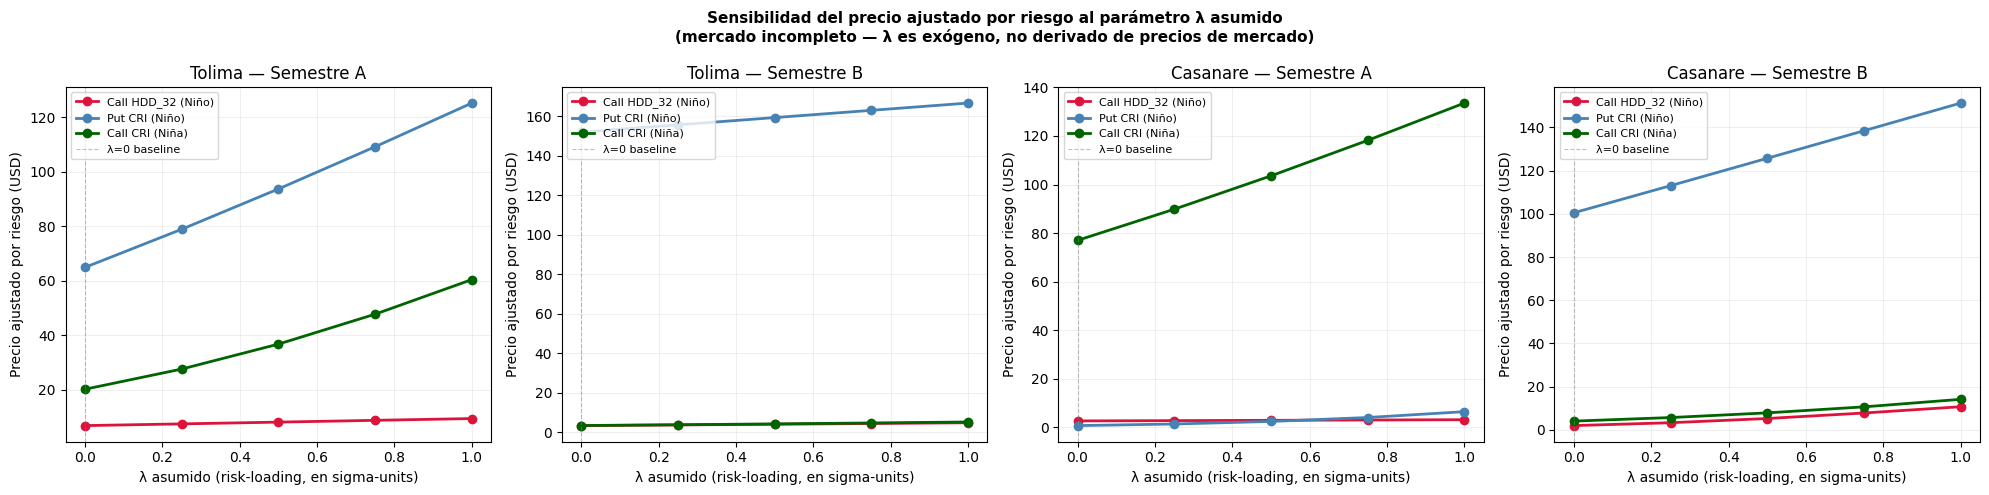

In [24]:
COLORES_CONTRATO = {f"Call {HDD_COL}": "crimson", "Put CRI": "steelblue", "Call CRI": "darkgreen"}


def graficar_sensibilidad_lambda(sens):
    """Four-panel figure: risk-adjusted price sensitivity to assumed lambda.

    Each panel corresponds to one (dpto, semestre) group.
    Lambda is the exogenous risk-loading parameter; it is NOT a calibrated quantity.
    """
    grupos = sigmas_df[["dpto", "semestre"]].drop_duplicates().values.tolist()
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
    for ax, (dpto, sem) in zip(axes, grupos):
        for ctto in CONTRATOS:
            sub = sens[(sens["dpto"] == dpto) & (sens["semestre"] == sem)
                       & (sens["contrato"] == ctto["nombre"])
                       & (sens["fase"] == ctto["fase_adversa"])]
            if sub.empty: continue
            sub = sub.sort_values("lambda")
            ax.plot(sub["lambda"], sub["precio"], marker="o", lw=2,
                    color=COLORES_CONTRATO[ctto["nombre"]],
                    label=f"{ctto['nombre']} ({ctto['fase_adversa']})")
        ax.axvline(x=0, color="gray", lw=0.8, ls="--", alpha=0.5, label="λ=0 baseline")
        ax.set_title(f"{dpto} — Semestre {sem}")
        ax.set_xlabel("λ asumido (risk-loading, en sigma-units)")
        ax.set_ylabel("Precio ajustado por riesgo (USD)")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, loc="upper left")
    fig.suptitle(
        "Sensibilidad del precio ajustado por riesgo al parámetro λ asumido\n"
        "(mercado incompleto — λ es exógeno, no derivado de precios de mercado)",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


graficar_sensibilidad_lambda(sens)


## 7. Exportación


In [25]:
sens.round(4).to_csv(OUT_DIR / "precios_lambda_sensibilidad.csv", index=False)

print("Archivos exportados:")
print(f"  - precios_lambda_sensibilidad.csv  ({len(sens)} filas)")
print()
print("Contenido del archivo: precio ajustado por riesgo para cada combinación")
print("(dpto, semestre, fase, contrato, lambda_asumido).")
print("Lambda es el parámetro de risk-loading exógeno, no un lambda derivado de precios de mercado.")


Archivos exportados:
  - precios_lambda_sensibilidad.csv  (180 filas)

Contenido del archivo: precio ajustado por riesgo para cada combinación
(dpto, semestre, fase, contrato, lambda_asumido).
Lambda es el parámetro de risk-loading exógeno, no un lambda derivado de precios de mercado.
